## Imports

In [1]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message, display_graph

## Single Node Graph

In [2]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str 

In [3]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }


In [4]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

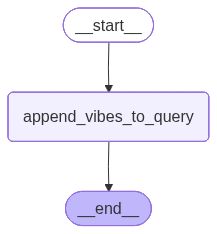

In [5]:
display_graph(graph)

In [6]:
initial_state = {
    "message": "Give me some vibes.",
    "vibe": "I'm feeling like a badass today."
}

In [7]:
result = graph.invoke(initial_state)

In [8]:
result

{'message': 'Give me some vibes.',
 'answer': "Give me some vibes. I'm feeling like a badass today.",
 'vibe': "I'm feeling like a badass today."}

## Conditional Graph

In [9]:
class State(BaseModel):
    message: str
    answer: str = ""
    

In [10]:
def append_vibes_to_query(state: State)-> dict:
    return {
        "answer": state.message
    }

In [11]:
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeling like a badass today."
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeling like a legend today."
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeling like a boss today."
    return {
        "answer": f"{state.message} {vibe}"
    }

In [12]:
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]

    vibe_path = random.choice(vibes)

    return vibe_path

In [13]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"

    }
)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

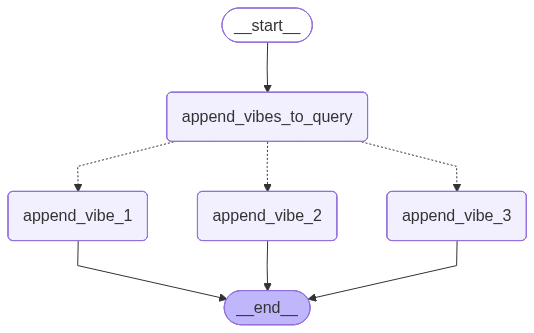

In [14]:
display_graph(graph)

In [15]:
initial_state = {
    "message": "Hi"
}

In [16]:
result = graph.invoke(initial_state)
result

{'message': 'Hi', 'answer': "Hi I'm feeling like a boss today."}

## Agent Graph

In [17]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    return f"{query} {vibe}"


In [18]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query.'}},
   'required': ['query', 'vibe']},
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended.'}}]

In [19]:
class ToolCall(BaseModel):
    name: str
    arguments: dict

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall]

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [20]:
def agent_node(state: State) -> dict:

    prompt_template = """
    
    You are an assistant that is generating vibes for a user.

    ## Tools

    <Available tools>
    {{ available_tools | tojson }}
    </Available tools>

    Use only the tool names listed above, exactly as written. Place all parameters inside the "arguments" object.

    ## Tool Call Examples

    - Append vibes to the user's query:
    {
    "name": "append_vibes",
    "arguments": {"query": "Give me some vibes!", "vibe": "I am feeling like a badass today!"}
    }

    ## Instructions

    - You need to use the tools to add vibes to the user's query.
    - Add a random vibe to the user's query.
    """

    template = Template(prompt_template)
    prompt = template.render(
        available_tools=state.available_tools
    )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
                {"role": "system", "content": prompt}
            ],
            response_model=AgentResponse
    )

    ai_message = format_ai_message(response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls
    }


## Explainer: OpenAI / Langgraph messages

In [21]:
# OpenAI
conversation  = [
    {'role': 'user', 'content': 'Give me some vibes!'},
    {'role': 'assistant', 'content': 'I am here to add some vibes:'},
    {'role': 'user', 'content': 'I am feeling like a badass today!'}
]

# Langgraph
convert_to_messages(conversation)


[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am feeling like a badass today!', additional_kwargs={}, response_metadata={})]

In [22]:
# Back to Openai
convert_to_openai_messages(convert_to_messages(conversation))


[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes:'},
 {'role': 'user', 'content': 'I am feeling like a badass today!'}]

In [23]:
dummy_response = AgentResponse(answer="I am here to add some vibes:", tool_calls=[ToolCall(name="append_vibes", arguments={"query": "Give me some vibes!", "vibe": "I am feeling like a badass today!"})])
dummy_response

AgentResponse(answer='I am here to add some vibes:', tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'})])

In [24]:
format_ai_message(dummy_response)


AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

## Sequential Agent

In [25]:
def tool_router(state: State):
    if len(state.tool_calls) > 0:
        return "tools"

    else:
        return "end"
        

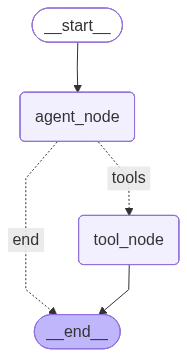

In [26]:
workflow = StateGraph(State)

tools = [append_vibes]

# Automatically check if AIMesssage in last messages
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START,"agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()

display_graph(graph)

In [27]:
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions
}

In [28]:
result = graph.invoke(initial_state)

In [30]:
result

{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'Radiating positive energy and good vibes!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! Radiating positive energy and good vibes!', name='append_vibes', tool_call_id='call_0')],
 'message': 'Give me some vibes!',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to append the vibe to.'},
     'vibe': {'type': 'string',
      'description': 'The vibe to append to the query.'}},
    'required': ['query', 'vibe']},
   'returns': {'type': 'string',
    'description': 'A string with the query and vibe appended.'}}],
 'tool_calls': [ToolCall(name='append_

## Loop back to Agent (ReAct Agent)

In [31]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    
    return f"{query} {vibe}"    

In [32]:
class ToolCall(BaseModel):
    name: str
    arguments: dict

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [33]:
def agent_node(state: State) -> dict:

    prompt_template = """You are an assistant that is generating vibes for a user.

## Tools

<Available tools>
{{ available_tools | tojson }}
</Available tools>

Use only the tool names listed above, exactly as written. Place all parameters inside the "arguments" object.

## Tool Call Examples

- Append vibes to the user's query:
{
   "name": "append_vibes",
   "arguments": {"query": "Give me some vibes!", "vibe": "I am feeling like a badass today!"}
}

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- You must return a tool call in the first interaction.
"""

    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )

    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=AgentResponse
    )

    ai_message = format_ai_message(response)

    
    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer
    }

In [34]:
def tool_router(state: State) -> dict:

    if state.iteration > 2:
        return "end"
    elif len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

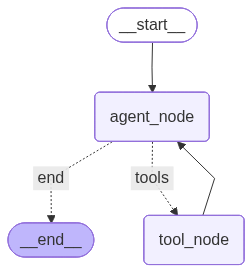

In [35]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
# Turns into React
workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()
display_graph(graph)

In [36]:
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions
}

In [37]:
result = graph.invoke(initial_state)

In [38]:
result

{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'Feeling adventurous and ready to explore new horizons!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! Feeling adventurous and ready to explore new horizons!', name='append_vibes', tool_call_id='call_0'),
  AIMessage(content='Give me some vibes! Feeling adventurous and ready to explore new horizons!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'message': 'Give me some vibes!',
 'iteration': 2,
 'answer': 'Give me some vibes! Feeling adventurous and ready to explore new horizons!',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'desc